# 04 - Lightweight Deep Learning Model ESA-ADB Mission1

**What we know from preprocessing (03_baseline_model.ipynb):**
- Best baseline : `IsolationForest` (F1=0.237, Precision=0.176, ROC-AUC=0.606)
- Flattening `(64, 6)` -> `(384,)` (destroyed temporal structure, one of the main weakness of sklearn baselines)
- `pos_weight = 8.5` for class imbalance
- Starter channels `channel_41` -> `channel_46`, windows already scaled & saved

**Objectives:**
- Build a lightweight GRU in PyTorch that preserves temporal structure within each window
- Train with `BCEWithLogitsLoss(pos_weight=8.5)` to handle class imbalance
- Evaluate and compare against `IsolationForest` baseline on F1, Precision, Recall and ROC-AUC
- Tune decision threshold to minimise false alarms
- Export best checkpoint to `models/trained/`

Sources :

1. [Differences between RNN, LSTM and GRU](https://lbourdois.github.io/blog/nlp/RNN-LSTM-GRU-ELMO/)

2. [GRU alternative of LSTM](https://datascience.stackexchange.com/questions/14581/when-to-use-gru-over-lstm)

3. [GRAD : Gated Recurrent Anomaly Detection](https://arxiv.org/html/2510.23327v1)

---
## Import & Paths

In [1]:
import json
import warnings
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
BG        = "#FAFAFA"
PANEL     = "#FFFFFF"
NORMAL_C  = "#2E5FA3"
ANOMALY_C = "#C0392B"
TEXT_DARK = "#1A1A2E"
TEXT_GRAY = "#6B7280"
ACCENT    = "#E8ECF4"

from IPython.display import display, Markdown
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve,
    classification_report, average_precision_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

ROOT = Path("..")
DATA_PROC = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results" / "metrics"
FIGURES_DIR = ROOT / "results" / "figures"
MODELS_DIR = ROOT / "models"  / "trained"

for d in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

for p in [DATA_PROC / "X_train_starter.npy",
          DATA_PROC / "y_train_starter.npy",
          DATA_PROC / "X_test_starter.npy"]:
    status = "File exist : " if p.exists() else "File missing : "
    print(f"{status}  {p}")


if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

# Global seed (without this, model init + DataLoader shuffling are non-deterministic,
# so reruns can converge to a noticeably different (better or worse) local optimum)
SEED = 42
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

print(f"\nDevice: {DEVICE}")
print(f"Seed  : {SEED}")

File exist :   ../data/processed/X_train_starter.npy
File exist :   ../data/processed/y_train_starter.npy
File exist :   ../data/processed/X_test_starter.npy

Device: mps
Seed  : 42


---
## Load Preprocessed Data

In [2]:
X_train_w = np.load(DATA_PROC / "X_train_starter.npy")
y_train_w = np.load(DATA_PROC / "y_train_starter.npy")
X_test_w = np.load(DATA_PROC / "X_test_starter.npy")

with open(RESULTS_DIR / "preprocessing_config.json") as f:
    config = json.load(f)

WINDOW_SIZE = config["window_size"]
STRIDE = config["stride"]
starter_cols = config["starter_channels"]
pos_weight = config["window_label_stats"]["pos_weight"]
win_ratio = config["window_label_stats"]["anomaly_ratio"]

# Load baseline results for comparison
with open(RESULTS_DIR / "baseline_results.json") as f:
    baseline_results = json.load(f)

iso_f1 = baseline_results["IsolationForest"]["f1"]
iso_precision = baseline_results["IsolationForest"]["precision"]
iso_recall = baseline_results["IsolationForest"]["recall"]
iso_roc_auc = baseline_results["IsolationForest"]["roc_auc"]

print(f"X_train_w  : {X_train_w.shape}  dtype={X_train_w.dtype}")
print(f"y_train_w  : {y_train_w.shape}        dtype={y_train_w.dtype}")
print(f"X_test_w   : {X_test_w.shape}    dtype={X_test_w.dtype}")
print(f"\nWindow size      : {WINDOW_SIZE}")
print(f"Starter channels : {starter_cols}")
print(f"Anomaly ratio    : {win_ratio:.2f} %")
print(f"pos_weight       : {pos_weight:.2f}")
print(f"\nBaseline to beat (IsolationForest) :")
print(f"  F1        : {iso_f1:.4f}")
print(f"  Precision : {iso_precision:.4f}")
print(f"  Recall    : {iso_recall:.4f}")
print(f"  ROC-AUC   : {iso_roc_auc:.4f}")

X_train_w  : (14728258, 64, 6)  dtype=float32
y_train_w  : (14728258,)        dtype=int8
X_test_w   : (521217, 64, 6)    dtype=float32

Window size      : 64
Starter channels : ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
Anomaly ratio    : 10.56 %
pos_weight       : 8.47

Baseline to beat (IsolationForest) :
  F1        : 0.2365
  Precision : 0.1761
  Recall    : 0.3600
  ROC-AUC   : 0.6064


---
## Train / Validation Split

Same mindset as notebook 03, a split of 20% of the train set is performed with `shuffle=False` (to preserve temporal order and avoid leakage from future anomaly windows)

There is no need to flatten the window before feeding it to the model because the GRU is designed to process a sequence in its original time order (unlike sklearn models)

In [3]:
VAL_RATIO = 0.20
SUBSAMPLE_RATIO = 0.05

split_idx = int(len(X_train_w) * (1 - VAL_RATIO))
X_tr_full, X_val_full = X_train_w[:split_idx], X_train_w[split_idx:]
y_tr_full, y_val_full = y_train_w[:split_idx], y_train_w[split_idx:]

# Subsample train only (for training speed)
rng = np.random.default_rng(SEED)

n_sub_train = int(len(X_tr_full) * SUBSAMPLE_RATIO)
sub_idx_tr = np.sort(rng.choice(len(X_tr_full), size=n_sub_train, replace=False))
X_tr = X_tr_full[sub_idx_tr]
y_tr = y_tr_full[sub_idx_tr]

# Small subsample of val for fast per-epoch monitoring during training
n_sub_val = int(len(X_val_full) * SUBSAMPLE_RATIO)
sub_idx_val = np.sort(rng.choice(len(X_val_full), size=n_sub_val, replace=False))
X_val = X_val_full[sub_idx_val]
y_val = y_val_full[sub_idx_val]

# X_val_full / y_val_full are kept and are used for the final baseline-comparable
# evaluation later because IsolationForest/RandomForest are scored on the FULL
# validation set and not a subsample
del X_tr_full, y_tr_full
import gc; gc.collect()

print(f"Train (subsampled)      : {X_tr.shape[0]:,} windows  ({y_tr.sum():,} anomalies : {y_tr.mean()*100:.2f} %)")
print(f"Val   (subsampled, monitoring only) : {X_val.shape[0]:,} windows  ({y_val.sum():,} anomalies : {y_val.mean()*100:.2f} %)")
print(f"Val   (full, used for final metrics): {X_val_full.shape[0]:,} windows  ({y_val_full.sum():,} anomalies : {y_val_full.mean()*100:.2f} %)")
print(f"\nSplit method : chronological then random subsample (seed={SEED})")

Train (subsampled)      : 589,130 windows  (62,285 anomalies : 10.57 %)
Val   (subsampled, monitoring only) : 147,282 windows  (15,604 anomalies : 10.59 %)
Val   (full, used for final metrics): 2,945,652 windows  (312,518 anomalies : 10.61 %)

Split method : chronological then random subsample (seed=42)


---
## PyTorch Dataset & DataLoader

A custom `TelemetryDataset` is created in order to wraps the numpy arrays into PyTorch tensors, one sample at a time for the Dataset/DataLoader pipeline

In [4]:
class TelemetryDataset(Dataset):
    """
    PyTorch Dataset for windowed telemetry data.

    Parameters
    X : np.ndarray  (n_windows, window_size, n_channels)
    y : np.ndarray  (n_windows,) - binary labels, None for test set
    """
    def __init__(self, X: np.ndarray, y: np.ndarray | None = None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

# Hyperparameters
BATCH_SIZE = 256

train_ds = TelemetryDataset(X_tr, y_tr)
val_ds = TelemetryDataset(X_val, y_val)
val_ds_full = TelemetryDataset(X_val_full, y_val_full)
test_ds = TelemetryDataset(X_test_w)

# Seeded generator so batch order is reproducible across reruns
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0, pin_memory=False,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)
# Larger batch size for the full validation set - eval only (no gradients)
val_loader_full = DataLoader(val_ds_full, batch_size=1024,
                          shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f"Batch size      : {BATCH_SIZE}")
print(f"Train batches   : {len(train_loader):,}")
print(f"Val   batches   : {len(val_loader):,}  (subsampled, per-epoch monitoring)")
print(f"Val   batches   : {len(val_loader_full):,}  (full set, batch_size=1024, final metrics)")
print(f"Test  batches   : {len(test_loader):,}")
print(f"\nSample batch shape : {next(iter(train_loader))[0].shape}")

Batch size      : 256
Train batches   : 2,302
Val   batches   : 576  (subsampled, per-epoch monitoring)
Val   batches   : 2,877  (full set, batch_size=1024, final metrics)
Test  batches   : 2,037

Sample batch shape : torch.Size([256, 64, 6])


---
## GRU Model Architecture

A lightweight GRU is chosen over LSTM because :
- it has fewer parameters so faster training and inference on edge hardware (Jetson Nano)
- it has competitive performance with LSTM on short sequences (window=64)
- GRU processes the sequence of 64 time steps and produces a hidden-state output at every step; a **max-pooling over all 64 steps** (not just the final one) is passed to a fully-connected classifier head - this lets the classifier react to the anomalous pattern wherever it occurs in the window, matching the "any-point" window labelling strategy

**Unidirectional vs bidirectional - tested both :** since the model classifies a complete, already-buffered 64-step window (not a raw incremental stream), there is no strict causality requirement forcing forward-only processing - bidirectional was a reasonable hypothesis to try, and would still be compatible with the sliding-window scoring design planned for the Jetson milestone (buffer a window, then run one inference pass on it - bidirectionality only uses data already inside that buffer).

In practice, on a controlled comparison (same seed, same data, same training pipeline, only this flag changed), **unidirectional won** on the full validation set (F1=0.269 vs 0.259, Precision=0.229 vs 0.212) while training ~2x faster. The per-epoch monitoring metric (computed on a 5% subsample) had actually favoured bidirectional during training, which didn't hold up on the full 2.95M-window evaluation - a reminder that the small monitoring subsample is noisy and the full-set number is the one that counts. `bidirectional=False` is the default below; `bidirectional=True` remains available as a constructor argument if worth revisiting with more training data later.

[PyTorch's GRU documentation](https://docs.pytorch.org/docs/2.13/generated/torch.nn.GRU.html) \
[Build GRU from scratch](https://medium.com/@sayedebad.777/building-rnn-lstm-and-gru-from-scratch-e27ebb0f8e0f)

In [5]:
class GRUAnomalyDetector(nn.Module):
    """
    Lightweight GRU (optionally bidirectional) for binary anomaly detection on telemetry windows

    Parameters
    n_features    : number of input channels (6 for starter channels)
    hidden_size   : GRU hidden dimension (per direction)
    num_layers    : number of recurrent GRU layers (the more the layers, to more
                    complex is the hierarchical patterns -> can leads to overfitting if big number)
    dropout       : dropout probability between GRU layers (reduce overtiffing
                    by randomly ignoring some neurons outputs during training)
    bidirectional : if True, runs a forward + backward GRU pass and concatenates their
                    outputs (num_directions=2); if False, forward-only (num_directions=1).
                    Tested both (see markdown above) - forward-only wins on the full
                    validation set, so it is the default here.
    """
    def __init__(self,
                 n_features: int = 6,
                 hidden_size: int = 64,
                 num_layers: int = 2,
                 dropout: float = 0.3,
                 bidirectional: bool = False):
        super().__init__()

        num_directions = 2 if bidirectional else 1

        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * num_directions, 32),   # num_directions = 2 means forward + backward directions concatenated
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # x (input shape) : (batch, seq_len, n_features)
        output, _ = self.gru(x)             # (batch, seq_len, hidden_size * num_directions)
        pooled, _ = output.max(dim=1)       # (batch, hidden_size * num_directions) - max over the 64 timesteps
        logits = self.classifier(pooled)
        return logits.squeeze(1)            # (batch,)


# Initializing parameters
N_FEATURES = X_tr.shape[2]
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.2
BIDIRECTIONAL = False   # tested True vs False (seeded, controlled) - False won on the full val set and is 2x faster

torch.manual_seed(SEED)   # re-seed right before model init for reproducible weights
model = GRUAnomalyDetector(
    n_features=N_FEATURES,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters : {n_params:,}")
print(f"Device               : {DEVICE}")

GRUAnomalyDetector(
  (gru): GRU(6, 64, batch_first=True)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters : 15,937
Device               : mps


---
## Training Setup

- **Loss :** `BCEWithLogitsLoss(pos_weight=8.5)` to upweights anomaly class by 8.5 times to compensate for the 8.5:1 imbalance (this directly penalises missed anomalies more than false alarms)
- **Optimiser :** `Adam(lr=1e-3)` (the optimiser is used to update the weights of the GRU after each batch and Adam is a standard choice for recurrent models)
- **Gradient clipping :** `clip_grad_norm_(max_norm=1.0)` - `pos_weight` scales anomaly-sample gradients up to ~8.5x, clipping stabilises training
- **Scheduler :** `ReduceLROnPlateau` (halves the learning rate if validation PR-AUC stops improving for 4 epochs). It prevents oscillation in later epochs
- **Early stopping :** stops training if validation **PR-AUC** (threshold-independent) does not improve for **10** consecutive epochs and it saves the best checkpoint automatically

In [6]:
N_EPOCHS = 40
LR = 1e-3
PATIENCE = 10

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32).to(DEVICE)
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=4
)

print(f"Loss      : BCEWithLogitsLoss  (pos_weight={pos_weight:.2f})")
print(f"Optimiser : Adam               (lr={LR})")
print(f"Scheduler : ReduceLROnPlateau  (patience=4, factor=0.5)")
print(f"Epochs    : {N_EPOCHS}")
print(f"Early stop patience : {PATIENCE} epochs on val PR-AUC")

Loss      : BCEWithLogitsLoss  (pos_weight=8.47)
Optimiser : Adam               (lr=0.001)
Scheduler : ReduceLROnPlateau  (patience=4, factor=0.5)
Epochs    : 40
Early stop patience : 10 epochs on val PR-AUC


---
## Training Loop

In [7]:
from tqdm import tqdm

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in tqdm(loader, desc="Train", total=len(loader)):
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(X_batch)

    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y_batch.cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = (all_probs >= threshold).astype(int)
    f1 = f1_score(all_labels, preds, zero_division=0)
    # PR-AUC is threshold-independent - more stable metric for model
    # selection while pos_weight keeps shifting the probability distribution
    pr_auc = average_precision_score(all_labels, all_probs)
    return total_loss / len(loader.dataset), f1, pr_auc, all_probs, all_labels


# Training
history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_pr_auc": [], "lr": []}
best_val_pr_auc = 0.0
best_val_f1 = 0.0
patience_ctr = 0
best_ckpt = MODELS_DIR / "gru_best.pt"

print(f"{'Epoch':<7} {'Train Loss':<13} {'Val Loss':<12} {'Val F1':<10} {'Val PR-AUC':<12} {'LR'}")
print("-" * 68)

t_start = time.perf_counter()

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_f1, val_pr_auc, val_probs, val_labels = eval_epoch(
        model, val_loader, criterion, DEVICE
    )
    scheduler.step(val_pr_auc)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["val_pr_auc"].append(val_pr_auc)
    history["lr"].append(current_lr)

    print(f"{epoch:<7} {train_loss:<13.4f} {val_loss:<12.4f} {val_f1:<10.4f} {val_pr_auc:<12.4f} {current_lr:.2e}")

    # Early stopping, driven by PR-AUC
    if val_pr_auc > best_val_pr_auc:
        best_val_pr_auc = val_pr_auc
        best_val_f1 = val_f1
        patience_ctr = 0
        torch.save(model.state_dict(), best_ckpt)
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} - best val PR-AUC : {best_val_pr_auc:.4f}  "
                  f"(val F1 at that epoch : {best_val_f1:.4f})")
            break

total_time = time.perf_counter() - t_start

print(f"\nTraining completed in {total_time:.1f} s")
print(f"Best checkpoint saved : {best_ckpt}")

python(30951) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch   Train Loss    Val Loss     Val F1     Val PR-AUC   LR
--------------------------------------------------------------------


Train: 100%|██████████| 2302/2302 [01:31<00:00, 25.17it/s]


1       1.1400        1.2732       0.1712     0.1163       1.00e-03


Train: 100%|██████████| 2302/2302 [01:25<00:00, 27.05it/s]


...

30      1.0799        1.2705       0.2052     0.1748       2.50e-04


Train: 100%|██████████| 2302/2302 [01:24<00:00, 27.16it/s]


31      1.0795        1.2073       0.2104     0.2429       2.50e-04


Train: 100%|██████████| 2302/2302 [01:24<00:00, 27.13it/s]


32      1.0794        1.2466       0.2067     0.1809       1.25e-04

Early stopping at epoch 32 - best val PR-AUC : 0.2652  (val F1 at that epoch : 0.2159)

Training completed in 3012.0 s
Best checkpoint saved : ../models/trained/gru_best.pt


---
## Training Curves

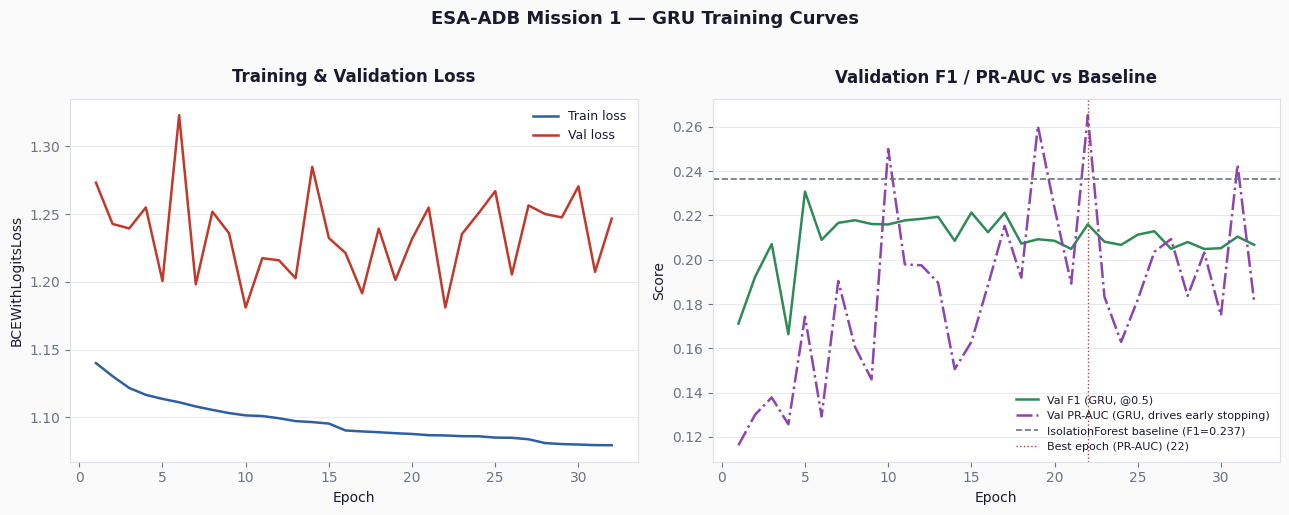

In [8]:
epochs_ran = len(history["train_loss"])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color("#DDE1E7")

# Loss
axes[0].plot(x, history["train_loss"], color=NORMAL_C, lw=1.8, label="Train loss")
axes[0].plot(x, history["val_loss"], color=ANOMALY_C, lw=1.8, label="Val loss")
axes[0].set_xlabel("Epoch", fontsize=10, color=TEXT_DARK)
axes[0].set_ylabel("BCEWithLogitsLoss", fontsize=10, color=TEXT_DARK)
axes[0].set_title("Training & Validation Loss",
                  fontsize=12, fontweight="bold", color=TEXT_DARK, pad=12)
axes[0].legend(fontsize=9, frameon=False, labelcolor=TEXT_DARK)
axes[0].tick_params(colors=TEXT_GRAY)
axes[0].yaxis.grid(True, color="#DDE1E7", lw=0.5)
axes[0].set_axisbelow(True)

# Val F1 / PR-AUC
DL_C = "#2E8B57"
PRAUC_C = "#8E44AD"
axes[1].plot(x, history["val_f1"], color=DL_C, lw=1.8, label="Val F1 (GRU, @0.5)")
axes[1].plot(x, history["val_pr_auc"], color=PRAUC_C, lw=1.8, ls="-.",
             label="Val PR-AUC (GRU, drives early stopping)")
axes[1].axhline(iso_f1, color=TEXT_GRAY, lw=1.2, ls="--",
                label=f"IsolationForest baseline (F1={iso_f1:.3f})")
best_epoch = int(np.argmax(history["val_pr_auc"])) + 1
axes[1].axvline(best_epoch, color=ANOMALY_C, lw=1.0, ls=":",
                label=f"Best epoch (PR-AUC) ({best_epoch})")
axes[1].set_xlabel("Epoch", fontsize=10, color=TEXT_DARK)
axes[1].set_ylabel("Score", fontsize=10, color=TEXT_DARK)
axes[1].set_title("Validation F1 / PR-AUC vs Baseline",
                  fontsize=12, fontweight="bold", color=TEXT_DARK, pad=12)
axes[1].legend(fontsize=8, frameon=False, labelcolor=TEXT_DARK)
axes[1].tick_params(colors=TEXT_GRAY)
axes[1].yaxis.grid(True, color="#DDE1E7", lw=0.5)
axes[1].set_axisbelow(True)

plt.suptitle("ESA-ADB Mission 1 — GRU Training Curves",
             fontsize=13, fontweight="bold", color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gru_training_curves.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Threshold Tuning

The default threshold of 0.5 is rarely optimal for imbalanced datasets.
Since the ESA ops requirement is to **minimise false alarms**, we search
for the threshold that maximises **F1** while keeping **Recall ≥ 0.30**
(we must still detect at least 30% of real anomalies to be operationally useful).
Precision is reported alongside F1 to make the false-alarm trade-off visible,
but F1 (not precision alone) is the objective driving the threshold choice.

Note: probabilities are computed on `val_loader_full` (the **full** validation split,
same one used by IsolationForest/RandomForest in notebook 03) rather than the 5%
subsample used for per-epoch monitoring during training. This makes the final
GRU metrics directly comparable to the baseline numbers.

Threshold search (recall >= 0.3) :
  Best threshold : 0.65
  F1             : 0.2638
  Precision      : 0.2318
  Recall         : 0.3061


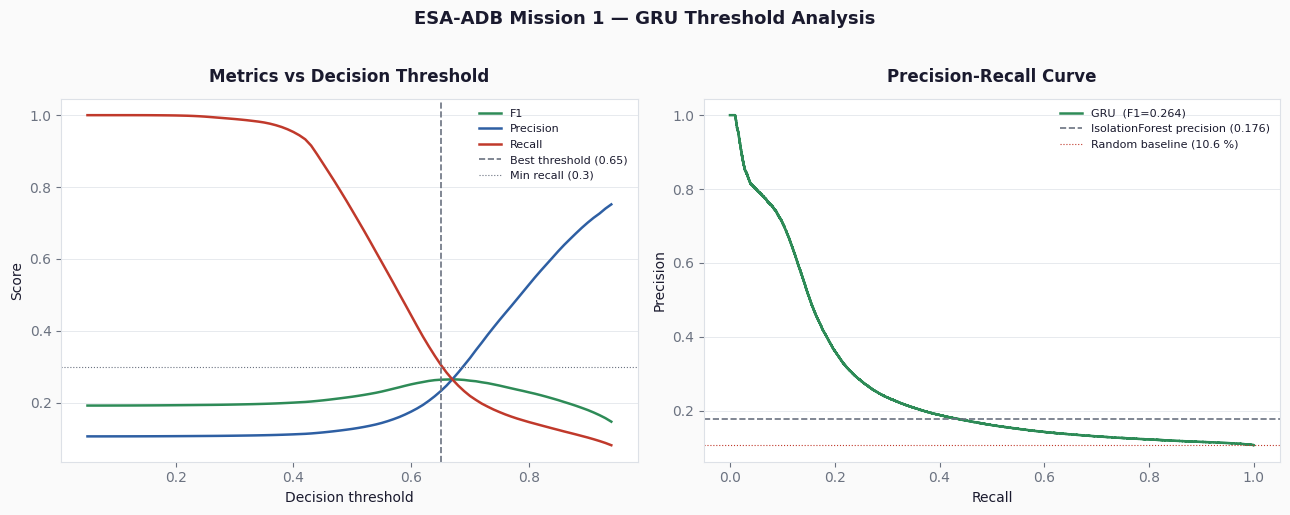

In [9]:
# Load best checkpoint
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model.eval()

# Evaluate on the full validation set
_, _, _, val_probs, val_labels = eval_epoch(
    model, val_loader_full, criterion, DEVICE, threshold=0.5
)

# Threshold search
thresholds = np.arange(0.05, 0.95, 0.01)
MIN_RECALL = 0.30
results_thr = []

for thr in thresholds:
    preds = (val_probs >= thr).astype(int)
    f1 = f1_score(val_labels, preds, zero_division=0)
    prec = precision_score(val_labels, preds, zero_division=0)
    rec = recall_score(val_labels, preds, zero_division=0)
    results_thr.append({"threshold": thr, "f1": f1,
                         "precision": prec, "recall": rec})

thr_df = pd.DataFrame(results_thr)
valid = thr_df[thr_df["recall"] >= MIN_RECALL]
best_row = valid.loc[valid["f1"].idxmax()] if not valid.empty \
           else thr_df.loc[thr_df["f1"].idxmax()]
BEST_THR = best_row["threshold"]

print(f"Threshold search (recall >= {MIN_RECALL}) :")
print(f"  Best threshold : {BEST_THR:.2f}")
print(f"  F1             : {best_row['f1']:.4f}")
print(f"  Precision      : {best_row['precision']:.4f}")
print(f"  Recall         : {best_row['recall']:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color("#DDE1E7")

axes[0].plot(thr_df["threshold"], thr_df["f1"],
             color=DL_C, lw=1.8, label="F1")
axes[0].plot(thr_df["threshold"], thr_df["precision"],
             color=NORMAL_C, lw=1.8, label="Precision")
axes[0].plot(thr_df["threshold"], thr_df["recall"],
             color=ANOMALY_C, lw=1.8, label="Recall")
axes[0].axvline(BEST_THR, color=TEXT_GRAY, lw=1.2, ls="--",
                label=f"Best threshold ({BEST_THR:.2f})")
axes[0].axhline(MIN_RECALL, color=TEXT_GRAY, lw=0.8, ls=":",
                label=f"Min recall ({MIN_RECALL})")
axes[0].set_xlabel("Decision threshold", fontsize=10, color=TEXT_DARK)
axes[0].set_ylabel("Score", fontsize=10, color=TEXT_DARK)
axes[0].set_title("Metrics vs Decision Threshold",
                  fontsize=12, fontweight="bold", color=TEXT_DARK, pad=12)
axes[0].legend(fontsize=8, frameon=False, labelcolor=TEXT_DARK)
axes[0].tick_params(colors=TEXT_GRAY)
axes[0].yaxis.grid(True, color="#DDE1E7", lw=0.5)
axes[0].set_axisbelow(True)

prec_c, rec_c, _ = precision_recall_curve(val_labels, val_probs)
axes[1].plot(rec_c, prec_c, color=DL_C, lw=1.8,
             label=f"GRU  (F1={best_row['f1']:.3f})")
axes[1].axhline(iso_precision, color=TEXT_GRAY, lw=1.2, ls="--",
                label=f"IsolationForest precision ({iso_precision:.3f})")
axes[1].axhline(win_ratio/100, color=ANOMALY_C, lw=0.8, ls=":",
                label=f"Random baseline ({win_ratio:.1f} %)")
axes[1].set_xlabel("Recall",    fontsize=10, color=TEXT_DARK)
axes[1].set_ylabel("Precision", fontsize=10, color=TEXT_DARK)
axes[1].set_title("Precision-Recall Curve",
                  fontsize=12, fontweight="bold", color=TEXT_DARK, pad=12)
axes[1].legend(fontsize=8, frameon=False, labelcolor=TEXT_DARK)
axes[1].tick_params(colors=TEXT_GRAY)
axes[1].yaxis.grid(True, color="#DDE1E7", lw=0.5)
axes[1].set_axisbelow(True)

plt.suptitle("ESA-ADB Mission 1 — GRU Threshold Analysis",
             fontsize=13, fontweight="bold", color=TEXT_DARK, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gru_threshold_analysis.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Final Evaluation at Best Threshold

GRU - Final Validation Metrics (threshold=0.65) :
  F1        : 0.2638
  Precision : 0.2318
  Recall    : 0.3061
  ROC-AUC   : 0.6355

              precision    recall  f1-score   support

      Normal       0.91      0.88      0.90   2633134
     Anomaly       0.23      0.31      0.26    312518

    accuracy                           0.82   2945652
   macro avg       0.57      0.59      0.58   2945652
weighted avg       0.84      0.82      0.83   2945652



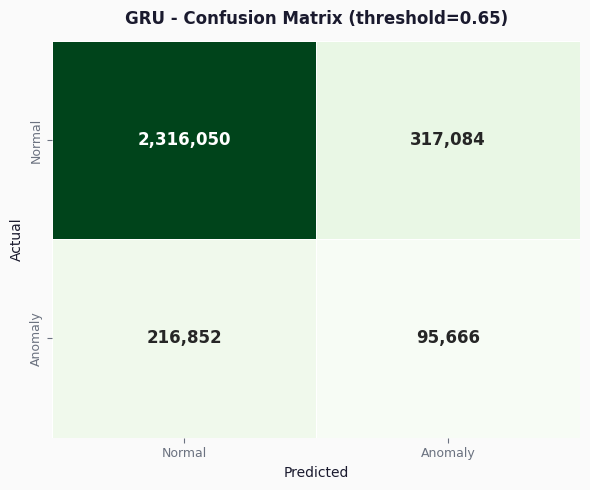

In [10]:
gru_pred = (val_probs >= BEST_THR).astype(int)
gru_f1 = f1_score(val_labels, gru_pred)
gru_precision = precision_score(val_labels, gru_pred)
gru_recall = recall_score(val_labels, gru_pred)
gru_roc_auc = roc_auc_score(val_labels, val_probs)

print(f"GRU - Final Validation Metrics (threshold={BEST_THR:.2f}) :")
print(f"  F1        : {gru_f1:.4f}")
print(f"  Precision : {gru_precision:.4f}")
print(f"  Recall    : {gru_recall:.4f}")
print(f"  ROC-AUC   : {gru_roc_auc:.4f}")
print()
print(classification_report(val_labels, gru_pred,
                             target_names=["Normal", "Anomaly"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
ax.set_facecolor(PANEL)
for spine in ax.spines.values():
    spine.set_color("#DDE1E7")

cm = confusion_matrix(val_labels, gru_pred)
sns.heatmap(
    cm, ax=ax,
    annot=True, fmt=",", cmap="Greens",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"],
    cbar=False, linewidths=0.5,
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted", fontsize=10, color=TEXT_DARK)
ax.set_ylabel("Actual",    fontsize=10, color=TEXT_DARK)
ax.set_title(f"GRU - Confusion Matrix (threshold={BEST_THR:.2f})",
             fontsize=12, fontweight="bold", color=TEXT_DARK, pad=12)
ax.tick_params(colors=TEXT_GRAY, labelsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "gru_confusion_matrix.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Model Comparison - GRU vs Baselines

### Model comparison - validation set

,Type,F1,Precision,Recall,ROC-AUC
Model,,,,,
IsolationForest,Unsupervised,0.2365,0.1761,0.3600,0.6064
RandomForest,Supervised,0.1689,0.1056,0.4219,0.5180
GRU,Deep Learning,0.2638,0.2318,0.3061,0.6355



-> Best model by F1 : GRU  (F1=0.2638)


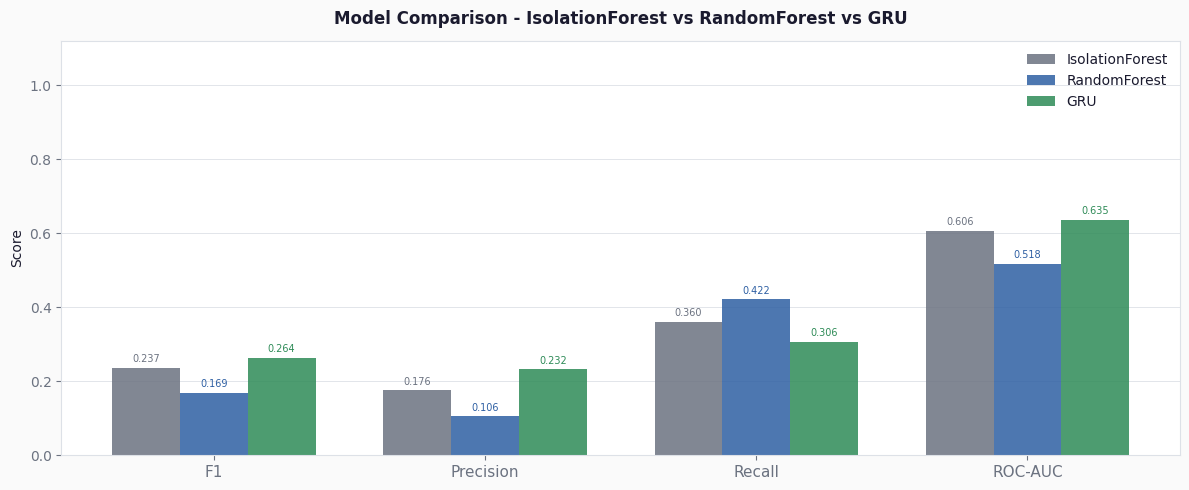

In [11]:
DL_C = "#2E8B57"

comparison = pd.DataFrame({
    "Model" : ["IsolationForest", "RandomForest", "GRU"],
    "Type" : ["Unsupervised", "Supervised", "Deep Learning"],
    "F1" : [iso_f1, baseline_results["RandomForest"]["f1"], gru_f1],
    "Precision" : [iso_precision, baseline_results["RandomForest"]["precision"], gru_precision],
    "Recall" : [iso_recall, baseline_results["RandomForest"]["recall"], gru_recall],
    "ROC-AUC" : [iso_roc_auc, baseline_results["RandomForest"]["roc_auc"], gru_roc_auc],
}).set_index("Model")

display(Markdown("### Model comparison - validation set"))
display(comparison)

best_model = comparison["F1"].idxmax()
print(f"\n-> Best model by F1 : {best_model}  (F1={comparison.loc[best_model, 'F1']:.4f})")

# Bar chart
metrics  = ["F1", "Precision", "Recall", "ROC-AUC"]
iso_vals = [iso_f1, iso_precision, iso_recall, iso_roc_auc]
rf_vals  = [baseline_results["RandomForest"]["f1"],
            baseline_results["RandomForest"]["precision"],
            baseline_results["RandomForest"]["recall"],
            baseline_results["RandomForest"]["roc_auc"]]
gru_vals = [gru_f1, gru_precision, gru_recall, gru_roc_auc]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
ax.set_facecolor(PANEL)
for spine in ax.spines.values():
    spine.set_color("#DDE1E7")

bars1 = ax.bar(x - width, iso_vals, width, label="IsolationForest",
               color=TEXT_GRAY, alpha=0.85, zorder=2)
bars2 = ax.bar(x, rf_vals, width, label="RandomForest",
               color=NORMAL_C, alpha=0.85, zorder=2)
bars3 = ax.bar(x + width, gru_vals, width, label="GRU",
               color=DL_C, alpha=0.85, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11, color=TEXT_DARK)
ax.set_ylabel("Score", fontsize=10, color=TEXT_DARK)
ax.set_ylim(0, 1.12)
ax.tick_params(colors=TEXT_GRAY)
ax.yaxis.grid(True, color="#DDE1E7", lw=0.6, zorder=0)
ax.set_axisbelow(True)

for bars, col in [(bars1, TEXT_GRAY), (bars2, NORMAL_C), (bars3, DL_C)]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f"{bar.get_height():.3f}", ha="center", fontsize=7, color=col)

ax.legend(fontsize=10, frameon=False, labelcolor=TEXT_DARK)
ax.set_title("Model Comparison - IsolationForest vs RandomForest vs GRU",
             fontsize=12, fontweight="bold", color=TEXT_DARK, pad=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_gru.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

---
## Save Model & Results

In [12]:
model_config = {
    "architecture" : "GRU",
    "bidirectional": BIDIRECTIONAL,
    "seed"         : SEED,
    "n_features"   : N_FEATURES,
    "hidden_size"  : HIDDEN_SIZE,
    "num_layers"   : NUM_LAYERS,
    "dropout"      : DROPOUT,
    "window_size"  : WINDOW_SIZE,
    "starter_cols" : starter_cols,
    "best_threshold": float(BEST_THR),
    "training": {
        "n_epochs"      : N_EPOCHS,
        "batch_size"    : BATCH_SIZE,
        "lr"            : LR,
        "weight_decay"  : 1e-4,
        "pos_weight"    : float(pos_weight),
        "patience"      : PATIENCE,
        "epochs_ran"    : epochs_ran,
        "best_val_f1"   : float(best_val_f1),
        "best_val_pr_auc": float(best_val_pr_auc),
        "subsample_ratio": SUBSAMPLE_RATIO,
    },
    "val_metrics": {
        "f1"        : float(gru_f1),
        "precision" : float(gru_precision),
        "recall"    : float(gru_recall),
        "roc_auc"   : float(gru_roc_auc),
    },
    "vs_baseline_iso": {
        "f1_delta"        : float(gru_f1 - iso_f1),
        "precision_delta" : float(gru_precision - iso_precision),
        "recall_delta"    : float(gru_recall - iso_recall),
        "roc_auc_delta"   : float(gru_roc_auc - iso_roc_auc),
    }
}

config_path = MODELS_DIR / "gru_config.json"
with open(config_path, "w") as f:
    json.dump(model_config, f, indent=2)

comparison.to_csv(RESULTS_DIR / "model_comparison_gru.csv")

print(f"File exist :  {best_ckpt}")
print(f"File exist :  {config_path}")
print(f"File exist :  {RESULTS_DIR / 'model_comparison_gru.csv'}")

print(f"\nDelta vs IsolationForest baseline :")
print(f"  ΔF1        : {gru_f1 - iso_f1:+.4f}")
print(f"  ΔPrecision : {gru_precision - iso_precision:+.4f}")
print(f"  ΔRecall    : {gru_recall - iso_recall:+.4f}")
print(f"  ΔROC-AUC   : {gru_roc_auc - iso_roc_auc:+.4f}")

File exist :  ../models/trained/gru_best.pt
File exist :  ../models/trained/gru_config.json
File exist :  ../results/metrics/model_comparison_gru.csv

Delta vs IsolationForest baseline :
  ΔF1        : +0.0273
  ΔPrecision : +0.0556
  ΔRecall    : -0.0539
  ΔROC-AUC   : +0.0290
